# Validate Low-Cost Sensor Data Against Reference Monitors in Python

**Goal:** Compare a PurpleAir low-cost sensor against the nearest AURN reference
monitor to assess data reliability and understand sensor performance.

**API keys required:** `PURPLEAIR_API_KEY`

**Aeolus features demonstrated:**
- Cross-source data retrieval with `download()` using dict format
- `find_sites()` for spatial discovery across different networks
- Standard schema enabling seamless cross-source joins
- `metrics.time_average()` for temporal alignment
- `viz.plot_timeseries()` for multi-source overlay
- QA tiers (`qa_tier`) across sources

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Check required API key
if not os.environ.get("PURPLEAIR_API_KEY"):
    raise EnvironmentError(
        "PURPLEAIR_API_KEY is required for this notebook.\n"
        "Get a free key at https://develop.purpleair.com/\n"
        "Then add it to your .env file: PURPLEAIR_API_KEY=your_key_here"
    )

In [2]:
import aeolus
from aeolus import metrics, viz
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Find a PurpleAir Sensor

Search for PurpleAir sensors in a London bounding box. We'll pick one that's
near an AURN reference monitor for a meaningful comparison.

In [3]:
# Find PurpleAir sensors in central London
pa_sites = aeolus.portals.find_sites(
    "PURPLEAIR",
    bbox=(-0.2, 51.48, 0.0, 51.55),  # (min_lon, min_lat, max_lon, max_lat)
)

print(f"Found {len(pa_sites)} PurpleAir sensors")
pa_sites[["site_code", "site_name", "latitude", "longitude"]].head()

Found 3 PurpleAir sensors


,site_code,site_name,latitude,longitude
0,188943,LSE CKK Indoors,51.515260,-0.117985
1,197637,Broadley Terrace,51.524357,-0.165868
2,199317,Eaton Place,51.497654,-0.152061


In [4]:
# Pick a sensor
pa_sensor = pa_sites.iloc[0]
pa_code = pa_sensor["site_code"]
pa_lat = pa_sensor["latitude"]
pa_lon = pa_sensor["longitude"]

print(f"Selected PurpleAir: {pa_sensor['site_name']} ({pa_code})")
print(f"Location: ({pa_lat:.4f}, {pa_lon:.4f})")

Selected PurpleAir: LSE CKK Indoors (188943)
Location: (51.5153, -0.1180)


## 2. Find the Nearest AURN Reference Monitor

Use `find_sites()` with the PurpleAir sensor's coordinates to find
the closest AURN reference-grade monitor.

In [5]:
# Find nearest AURN site to the PurpleAir sensor
aurn_sites = aeolus.find_sites(
    "AURN",
    near=(pa_lat, pa_lon),
    radius_km=10,
)

# find_sites() lists sites that are open today, but the nearest one may have
# opened after our study window (London Farringdon Street started in 2025),
# so take the nearest site that actually has data for the period.
start = datetime(2024, 6, 1)
end = datetime(2024, 6, 30)

for _, aurn_site in aurn_sites.iterrows():
    aurn_code = aurn_site["site_code"]
    if not aeolus.download("AURN", [aurn_code], start_date=start, end_date=end).empty:
        break

print(f"Nearest AURN with data for June 2024: {aurn_site['site_name']} ({aurn_code})")
print(f"Distance from PurpleAir: {aurn_site['distance_km']:.1f} km")

/Users/ruaraidhdobson/Dropbox/Personal/sls/aeolus/src/aeolus/networks/api.py:158: AeolusDataWarning: No data retrieved for AURN (sites=['LOFS'], years=[2024])
  return finalise_data_frame(fetcher(sites_, start_, end_), network)


Nearest AURN with data for June 2024: London Bloomsbury (CLL2)
Distance from PurpleAir: 1.0 km


## 3. Download Data from Both Sources

Download from both networks in a single call using the dict format.
Aeolus normalises both to the same 13-column schema, making the join trivial.

In [6]:
# Download 1 month from both sources (the AURN month is served from cache)
combined = aeolus.download(
    {
        "AURN": [aurn_code],
        "PURPLEAIR": [pa_code],
    },
    start_date=start,
    end_date=end,
)

print(f"Total records: {len(combined):,}")
print(f"\nRecords by source:")
print(combined.groupby("network").size())

Total records: 5,552

Records by source:
network
AURN         4872
PURPLEAIR     680
dtype: int64


In [7]:
# Compare QA tiers — reference_* for AURN; lcs_factory_only, flagged or unknown for PurpleAir
print("QA tiers by network:")
print(combined.groupby(["network", "qa_tier"]).size())

QA tiers by network:
network    qa_tier          
AURN       reference_full_qc    4872
PURPLEAIR  lcs_factory_only      408
           unknown               272
dtype: int64


## 4. Align Timestamps

Both sources produce UTC-aware hourly data (Aeolus standardises this).
We use `time_average()` to ensure consistent hourly alignment, then
pivot for a paired comparison.

In [8]:
# Filter to PM2.5 and compute hourly means (handles any sub-hourly data)
pm25 = combined[combined["measurand"] == "PM2.5"]

hourly = metrics.time_average(pm25, freq="h")

# Pivot: one column per source
paired = (
    hourly
    .pivot_table(index="date_time", columns="network", values="value")
    .dropna()
)

print(f"Paired hourly observations: {len(paired)}")
print(f"\nBasic statistics:")
paired.describe().round(1)

Paired hourly observations: 136

Basic statistics:


network,AURN,PURPLEAIR
count,136.0,136.0
mean,7.6,8.7
std,2.9,8.5
min,3.0,0.0
25%,5.2,3.4
50%,7.1,6.5
75%,9.5,11.1
max,14.2,57.1


## 5. Time Series Overlay

Plot both sensors on the same axis to visually assess agreement.

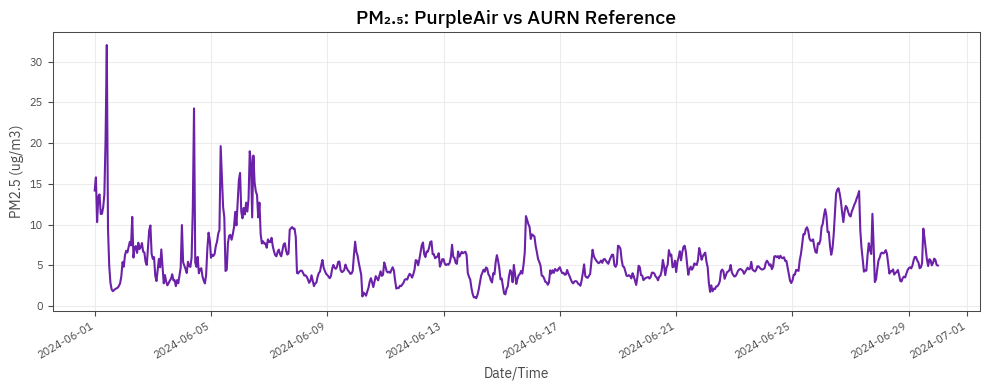

In [9]:
# Time series overlay
fig = viz.plot_timeseries(
    pm25,
    pollutants=["PM2.5"],
    title="PM\u2082.\u2085: PurpleAir vs AURN Reference",
)
plt.show()

## 6. Scatter Plot & Regression

A scatter plot with 1:1 line and regression statistics is the standard
method for evaluating sensor performance against a reference.

In [10]:
from scipy import stats

if paired.empty or len(paired.columns) < 2:
    print("Insufficient paired data for regression analysis.")
    print(f"Paired observations: {len(paired)}, columns: {paired.columns.tolist()}")
    slope = intercept = r_squared = rmse = bias = None
else:
    # Identify columns (source network names)
    cols = paired.columns.tolist()
    ref_col = [c for c in cols if "AURN" in c.upper()]
    ref_col = ref_col[0] if ref_col else cols[0]
    lcs_col = [c for c in cols if c != ref_col][0]

    x = paired[ref_col].values
    y = paired[lcs_col].values

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    # RMSE and bias
    rmse = np.sqrt(np.mean((y - x) ** 2))
    bias = np.mean(y - x)

    print(f"R\u00b2 = {r_squared:.3f}")
    print(f"Slope = {slope:.2f}, Intercept = {intercept:.1f}")
    print(f"RMSE = {rmse:.1f} \u00b5g/m\u00b3")
    over_under = 'overestimates' if bias > 0 else 'underestimates'
    print(f"Bias = {bias:+.1f} \u00b5g/m\u00b3 ({over_under})")

R² = 0.071
Slope = 0.77, Intercept = 2.8
RMSE = 8.2 µg/m³
Bias = +1.1 µg/m³ (overestimates)


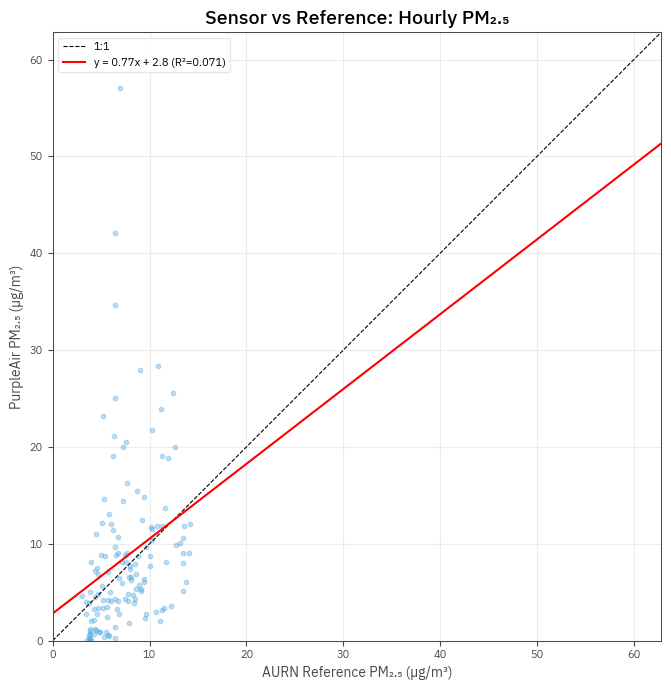

In [11]:
if slope is not None:
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(x, y, alpha=0.3, s=10, color="#3498db")

    # 1:1 line
    lim = max(x.max(), y.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="1:1")

    # Regression line
    x_fit = np.linspace(0, lim, 100)
    ax.plot(x_fit, slope * x_fit + intercept, "r-", linewidth=1.5,
            label=f"y = {slope:.2f}x + {intercept:.1f} (R\u00b2={r_squared:.3f})")

    ax.set_xlabel(f"AURN Reference PM\u2082.\u2085 (\u00b5g/m\u00b3)")
    ax.set_ylabel(f"PurpleAir PM\u2082.\u2085 (\u00b5g/m\u00b3)")
    ax.set_title("Sensor vs Reference: Hourly PM\u2082.\u2085")
    ax.legend()
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping scatter plot \u2014 no paired data available.")

## 7. Daily Aggregation Comparison

Low-cost sensors often perform better at daily resolution because
random noise averages out. Compare daily means.

In [12]:
# Daily means using time_average
daily = metrics.time_average(pm25, freq="D")

daily_paired = (
    daily[daily["measurand"] == "PM2.5"]
    .pivot_table(index="date_time", columns="network", values="value")
    .dropna()
)

if daily_paired.empty or len(daily_paired.columns) < 2 or slope is None:
    print("Insufficient paired daily data for comparison.")
else:
    # Daily regression
    xd, yd = daily_paired[ref_col].values, daily_paired[lcs_col].values
    slope_d, intercept_d, r_d, _, _ = stats.linregress(xd, yd)

    print(f"Daily R\u00b2 = {r_d**2:.3f} (vs hourly R\u00b2 = {r_squared:.3f})")
    daily_rmse = np.sqrt(np.mean((yd - xd)**2))
    print(f"Daily RMSE = {daily_rmse:.1f} \u00b5g/m\u00b3 (vs hourly RMSE = {rmse:.1f})")

Daily R² = 0.309 (vs hourly R² = 0.071)
Daily RMSE = 3.4 µg/m³ (vs hourly RMSE = 8.2)


## Summary

This notebook demonstrated:

1. **Cross-source discovery** — finding sensors and reference monitors spatially
2. **Multi-source download** — dict format for downloading from different networks in one call
3. **Standard schema** — seamless join on `date_time` because Aeolus normalises all sources
4. **Composable aggregation** — `time_average()` at different frequencies for hourly and daily comparisons
5. **QA tiers** — `qa_tier` distinguishes reference data (`reference_full_qc`, `reference_provisional`) from low-cost sensor data (`lcs_factory_only`, `flagged`, `unknown`)

### Interpreting results
- **R² > 0.7**: Reasonable agreement for a low-cost sensor
- **Positive bias**: PurpleAir tends to overestimate PM₂.₅ (common in humid conditions)
- **Better daily performance**: Expected — random noise cancels over 24h averages

### Next steps
- Apply a correction factor (e.g., EPA's PurpleAir correction)
- Extend to a full year to capture seasonal variation
- Compare Sensor.Community data as a third source